**01 - Carga y Análisis Exploratorio de Datos**

Este notebook correpsonde a la primera fase del proyecto final.
El objjetivo es cargar una muestra del dataset de reviews de Amazon, entender su estructura, revisar la calidad de los datos y analizar las principales variables antes de pasar a fases de limpieza, preprocesamiento y modelado.



El database proviene de este enlace https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/review_categories

In [ ]:
# 1. INSTALAR LIBRERÍAS

!pip install pandas matplotlib seaborn -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [ ]:
!wget -O reviews.jsonl https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl

--2026-06-16 17:40:51--  https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl
Resolving huggingface.co (huggingface.co)... 3.170.185.33, 3.170.185.14, 3.170.185.35, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.33|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cas-bridge.xethub.hf.co/xet-bridge-us/65af4645d0a5cc99d51642da/28866377eb7aec134fa8b5028e64a9d5de9960a671ef0babc5e0e177e1a96bc1?Expires=1781635251&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly9jYXMtYnJpZGdlLnhldGh1Yi5oZi5jby94ZXQtYnJpZGdlLXVzLzY1YWY0NjQ1ZDBhNWNjOTlkNTE2NDJkYS8yODg2NjM3N2ViN2FlYzEzNGZhOGI1MDI4ZTY0YTlkNWRlOTk2MGE2NzFlZjBiYWJjNWUwZTE3N2UxYTk2YmMxKiIsIkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc4MTYzNTI1MX19fV19&Signature=MEUCIBudE3p0YFqATmVMYJTiX6y0DImPQgOA5z5cB69x2ymsAiEAqisF7w5HO13adbh-pN4L2PrD8zOvhF2uqwSwHyDmWgM_&Key-Pair-Id=K1LYXO563TGWFU&X-Xet-Cas-Uid=public&response-co

In [ ]:
# Cargamos únicamente las primeras 50.000 reviews
# para trabajar con una muestra manejable del dataset
reviews = []

with open("reviews.jsonl", "r", encoding="utf-8") as archivo:

    for numero_review, linea in enumerate(archivo):

        if numero_review >= 50000:
            break

        reviews.append(json.loads(linea))

df = pd.DataFrame(reviews)

In [ ]:
df.head()
df.shape
df.info()
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             50000 non-null  float64
 1   title              50000 non-null  object 
 2   text               50000 non-null  object 
 3   images             50000 non-null  object 
 4   asin               50000 non-null  object 
 5   parent_asin        50000 non-null  object 
 6   user_id            50000 non-null  object 
 7   timestamp          50000 non-null  int64  
 8   helpful_vote       50000 non-null  int64  
 9   verified_purchase  50000 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 3.5+ MB


,0
rating,0
title,0
text,0
images,0
asin,0
parent_asin,0
user_id,0
timestamp,0
helpful_vote,0
verified_purchase,0


El dataset contiene 50.000 registros y varias columnas relacionadas con opiniones de productos: rating, título, texto de la review, identificador del producto, usuario, fecha, votos útiles y si la compra fue verificada.

¿Cómo son las valoraciones?






In [ ]:
df["rating"].value_counts().sort_index()

,count
rating,
1.0,4144
2.0,2117
3.0,3412
4.0,7383
5.0,32944


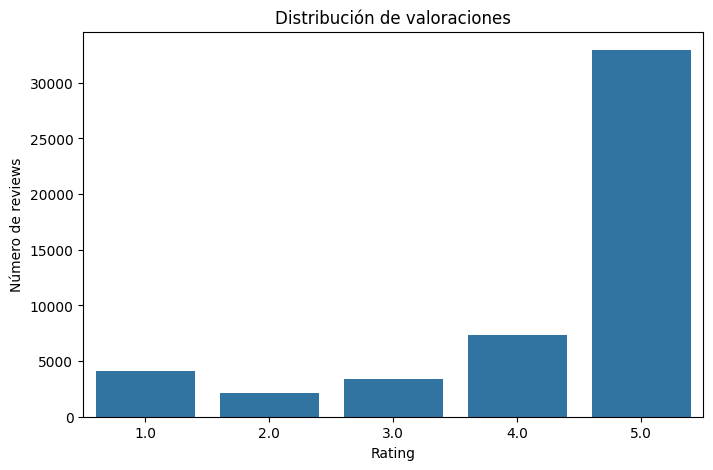

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="rating")

plt.title("Distribución de valoraciones")
plt.xlabel("Rating")
plt.ylabel("Número de reviews")

plt.show()

¿Cuántas son compras verificadas?

In [ ]:
df["verified_purchase"].value_counts()

,count
verified_purchase,
True,39116
False,10884


La mayoría de las opiniones (78,2%) proceden de compras verificadas, lo que aporta una mayor fiabilidad al conjunto de datos al tratarse de usuarios que realmente adquirieron el producto.

¿Cuánto texto tienen las reviews?

In [ ]:
df["review"] = df["title"] + " " + df["text"]
df["review_length"] = df["review"].str.len()
df["review_length"].describe()

,review_length
count,50000.000000
mean,395.680060
std,587.206956
min,3.000000
25%,85.000000
50%,207.000000
75%,449.000000
max,11514.000000


Las opiniones presentan una longitud considerable, lo que resulta muy positivo para posteriores tareas de Procesamiento del Lenguaje Natural (NLP).

Además, la gran diferencia entre la mediana y el valor máximo indica la existencia de algunas reseñas largas que podrían influir en determinados análisis.

¿Las reviews más útiles son más largas?

In [ ]:
df.sort_values(
    "helpful_vote",
    ascending=False
)[
    ["rating","helpful_vote","review_length"]
].head(20)

,rating,helpful_vote,review_length
43810,5.0,940,3821
631,5.0,777,1671
7192,5.0,736,9136
26063,4.0,451,4232
17009,5.0,417,2019
5394,4.0,321,3211
40923,5.0,315,791
5450,5.0,309,4811
20494,5.0,303,1025
25863,5.0,289,337


No parece existir una relación fuerte entre la verificación de compra y la valoración otorgada.

¿Los usuarios que compran de verdad valoran distinto?

In [ ]:
df.groupby(
    "verified_purchase"
)["rating"].mean()

,rating
verified_purchase,
False,4.330393
True,4.236987


¿La gente enfadada escirbe más que la gente contenta?

In [ ]:
df.groupby("rating")["review_length"].mean()

,review_length
rating,
1.0,352.187741
2.0,492.740671
3.0,531.801583
4.0,583.034539
5.0,338.828133


Los usuarios muy satisfechos suelen dejar comentarios breves

¿Las reviews negativas reciben más atención que las positivas?

In [ ]:
df.groupby("rating")["helpful_vote"].mean()

,helpful_vote
rating,
1.0,1.640927
2.0,1.282948
3.0,1.491794
4.0,1.446025
5.0,1.332807


¿Las reviews verificadas son más largas?

In [ ]:
df.groupby("verified_purchase")["review_length"].mean()

,review_length
verified_purchase,
False,816.772969
True,278.511249


¿Las reviews verificadas reciben más votos útiles ?

In [ ]:
df.groupby("verified_purchase")["helpful_vote"].mean()

,helpful_vote
verified_purchase,
False,1.842062
True,1.256289


Los consumidores parecen prestar una mayor atención a las opiniones negativas que a las positivas.

Cuando un usuario reporta un problema, otros compradores potenciales consideran esa información especialmente útil para evaluar riesgos antes de realizar una compra.

Las opiniones no verificadas presentan una longitud media significativamente superior (816 caracteres frente a 278) y reciben un mayor número de votos de utilidad. Esto sugiere que este tipo de reseñas suelen ser más detalladas y elaboradas, proporcionando información más extensa para otros consumidores.


 ## Conclusiones del EDA

* El dataset contiene 50.000 reviews de productos electrónicos y no presenta valores nulos.
* Existe un fuerte predominio de valoraciones positivas, especialmente de 5 estrellas.
* El 78% de las opiniones proceden de compras verificadas.
* Las reviews contienen suficiente texto para aplicar técnicas de NLP.
* Las opiniones más útiles suelen ser más largas y detalladas.
* Las reviews negativas reciben más votos de utilidad que las positivas.
* Las valoraciones intermedias (2-4 estrellas) son más extensas que las de 1 o 5 estrellas.
* Las reviews no verificadas son considerablemente más largas y reciben más votos útiles.
* El dataset presenta una calidad adecuada para desarrollar modelos de análisis de sentimiento y extracción de insights para ecommerce.

*   Elemento de lista

